In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("customer_churn_data.csv")

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [5]:
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [6]:
df["InternetService"]

0      Fiber Optic
1      Fiber Optic
2      Fiber Optic
3              DSL
4              NaN
          ...     
995    Fiber Optic
996            NaN
997    Fiber Optic
998            NaN
999            NaN
Name: InternetService, Length: 1000, dtype: object

In [7]:
df["InternetService"].isna().sum()

297

In [8]:
df["InternetService"] = df["InternetService"].fillna("")

In [9]:
df["InternetService"].isna().sum()

0

In [10]:
df.duplicated().sum()

0

In [11]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [12]:
numerical_columns_data = df.select_dtypes( include = ["number"] )

In [13]:
numerical_columns_data.head()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
0,1,49,4,88.35,353.40
1,2,43,0,36.67,0.00
2,3,51,2,63.79,127.58
3,4,60,8,102.34,818.72
4,5,42,32,69.01,2208.32


In [14]:
numerical_columns_data.corr()
# values towards -1 are strongly -ve
# values towards 1 are strongly +ve

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [15]:
df["Churn"].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

In [16]:
import matplotlib.pyplot as plt

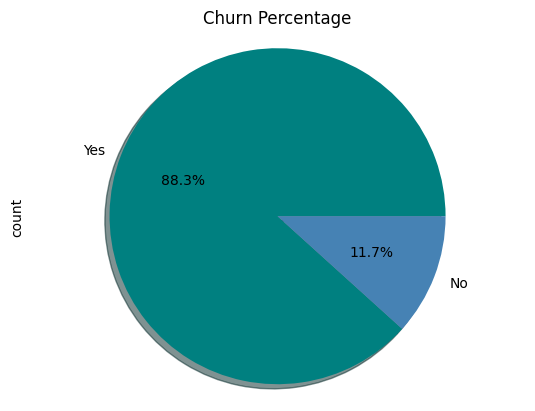

In [17]:
df["Churn"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=0,
    shadow=True,
    colors=['teal', 'steelblue']
)

plt.axis('equal')
plt.title('Churn Percentage')
plt.style.use('dark_background')

In [18]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [19]:
df.groupby(['Churn','Gender'])['MonthlyCharges'].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [20]:
df.groupby(['Churn','Gender'])[['Tenure','MonthlyCharges']].mean()

Tenure  MonthlyCharges
Churn Gender                           
No    Female  30.132353       65.091912
      Male    30.448980       59.013878
Yes   Female  17.048936       74.975064
      Male    17.963680       77.082518

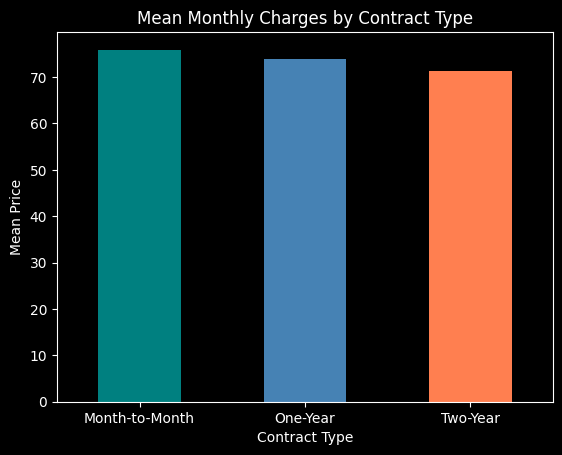

In [21]:
df.groupby('ContractType')['MonthlyCharges'].mean()\
.plot(kind='bar',
      rot=0,
      color=['teal', 'steelblue', 'coral']
)

plt.xlabel('Contract Type')
plt.ylabel('Mean Price')
plt.title('Mean Monthly Charges by Contract Type')
plt.show()


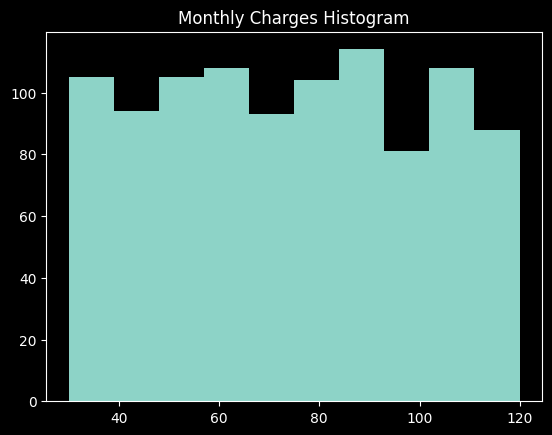

In [23]:
plt.hist(df['MonthlyCharges'])
plt.title('Monthly Charges Histogram')
plt.show()

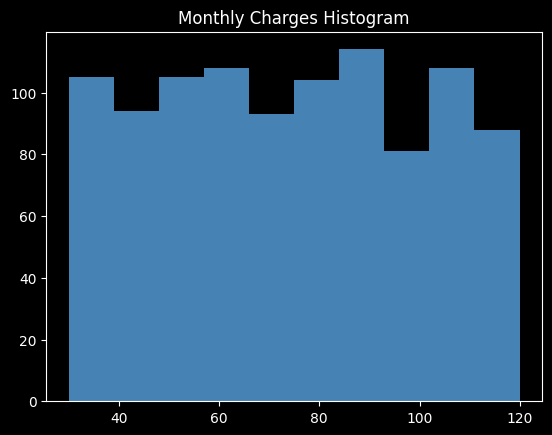

In [24]:
plt.hist(df['MonthlyCharges'], color='steelblue')
plt.title('Monthly Charges Histogram')
plt.show()

In [26]:
y = df[['Churn']]
y

,Churn
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
...,...
995,Yes
996,Yes
997,Yes
998,Yes


In [27]:
x = df[['Age','Gender','Tenure','MonthlyCharges']]
x

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [28]:
x['Gender'] = x['Gender'].apply(lambda x: 1 if x == 'Female' else 0)

C:\Users\abhis\AppData\Local\Temp\ipykernel_27636\2387561668.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Gender'] = x['Gender'].apply(lambda x: 1 if x == 'Female' else 0)


In [29]:
x.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [30]:
y.head()

,Churn
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes


In [31]:
y['Churn'] = y['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

C:\Users\abhis\AppData\Local\Temp\ipykernel_27636\884819502.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Churn'] = y['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)


In [35]:
y.head(10)

,Churn
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,0
9,1


In [34]:
y.sum()

Churn    883
dtype: int64